## Library Imports

In [1]:
import jax
import optax
import orbax
import random
import tiktoken
import gradio as gr
import pandas as pd
import flax.nnx as nnx
import jax.numpy as jnp
from pathlib import Path
from orbax import checkpoint
import grain.python as pygrain
import matplotlib.pyplot as plt
from jax.sharding import SingleDeviceSharding

In [2]:
NUM_EPOCHS = 20
MAX_STORIES = 200_000

In [3]:
train_data_path = '/kaggle/input/datasets/thedevastator/tinystories-narrative-classification/train.csv'
test_data_path = '/kaggle/input/datasets/thedevastator/tinystories-narrative-classification/validation.csv'

In [4]:
train_df = pd.read_csv(train_data_path)
test_df = pd.read_csv(test_data_path)
print(train_df.shape)
print(test_df.shape)

(2119719, 1)
(21990, 1)


In [5]:
train_df.dropna(inplace=True)
test_df.dropna(inplace=True)
print(train_df.shape)
print(test_df.shape)

(2119489, 1)
(21990, 1)


In [6]:
train_stories = train_df['text'].to_list()
test_stories = test_df['text'].to_list()

## Utility Functions

In [7]:
tokenizer = tiktoken.get_encoding("gpt2")

vocab_size = tokenizer.n_vocab
num_transformer_blocks = 6
maxlen = 128
embed_dim = 192
num_heads = 6
feed_forward_dim = int(2 / 3 * 4 * embed_dim)
batch_size = 24
num_epochs = 3

In [8]:
class TransformerBlock(nnx.Module):

    def __init__(self, embed_dim, num_heads, ff_dim, *, rngs):

        self.attention = nnx.MultiHeadAttention(
            num_heads=num_heads,
            in_features=embed_dim,
            qkv_features=embed_dim,
            out_features=embed_dim,
            decode=False,
            rngs=rngs,
        )

    def __call__(self, x, mask=None):
        attn_out = self.attention(x, mask=mask)
        x = x + attn_out
        return x

In [9]:
class TokenAndPositionEmbedding(nnx.Module):
    def __init__(self, maxlen, vocab_size, embed_dim, *, rngs):
        self.token_emb = nnx.Embed(vocab_size, embed_dim, rngs=rngs)
        self.pos_emb = nnx.Embed(maxlen, embed_dim, rngs=rngs)

    def __call__(self, x):
        seq_len = x.shape[1]
        positions = jnp.arange(seq_len)[None, :]
        return self.token_emb(x) + self.pos_emb(positions)

In [10]:
class MiniGPT(nnx.Module):

    def __init__(
        self,
        maxlen=maxlen,
        vocab_size=vocab_size,
        embed_dim=embed_dim,
        num_heads=num_heads,
        feed_forward_dim=feed_forward_dim,
        num_transformer_blocks=num_transformer_blocks,
        *,
        rngs=nnx.Rngs(0),
    ):

        self.maxlen = maxlen

        self.embedding = TokenAndPositionEmbedding(
            maxlen, vocab_size, embed_dim, rngs=rngs
        )

        self.transformer_blocks = [
            TransformerBlock(embed_dim, num_heads, feed_forward_dim, rngs=rngs)
            for _ in range(num_transformer_blocks)
        ]

        self.output_layer = nnx.Linear(embed_dim, vocab_size, use_bias=False, rngs=rngs)

    def causal_attention_mask(self, seq_len):
        return jnp.tril(jnp.ones((seq_len, seq_len)))

    def __call__(self, token_ids):
        seq_len = token_ids.shape[1]
        mask = self.causal_attention_mask(seq_len)

        x = self.embedding(token_ids)

        for block in self.transformer_blocks:
            x = block(x, mask=mask)

        logits = self.output_layer(x)

        return logits

In [11]:
def generate_text(model, start_tokens, max_new_tokens=50, temperature=1.0):
    tokens = list(start_tokens)

    for _ in range(max_new_tokens):
        context = tokens[-model.maxlen :]

        # RIGHT-pad to match training (not left-pad!)
        actual_len = len(context)
        if actual_len < model.maxlen:
            context = context + [0] * (model.maxlen - actual_len)

        context_array = jnp.array(context)[None, :]
        logits = model(context_array)

        next_token_logits = logits[0, actual_len - 1, :] / temperature

        next_token = int(jnp.argmax(next_token_logits))

        if (
            next_token
            == tokenizer.encode("<|endoftext|>", allowed_special={"<|endoftext|>"})[0]
        ):
            break

        tokens.append(next_token)

    return tokenizer.decode(tokens)

In [12]:
def generate_story(model, story_prompt, temperature, max_new_tokens):
    start_tokens = tokenizer.encode(story_prompt)[:maxlen]
    generated = generate_text(
        model, start_tokens, max_new_tokens=max_new_tokens, temperature=temperature
    )
    return generated

In [13]:
class StoryDataset:
    def __init__(self, stories, maxlen, tokenizer):
        self.stories = stories
        self.maxlen = maxlen
        self.tokenizer = tokenizer
        self.end_token = tokenizer.encode(
            "<|endoftext|>", allowed_special={"<|endoftext|>"}
        )[0]

    def __len__(self):
        return len(self.stories)

    def __getitem__(self, idx):
        story = self.stories[idx]
        tokens = self.tokenizer.encode(story, allowed_special={"<|endoftext|>"})

        if len(tokens) > self.maxlen:
            tokens = tokens[: self.maxlen]

        tokens.extend([0] * (self.maxlen - len(tokens)))
        return tokens

In [14]:
def load_and_preprocess_data(
    stories,
    batch_size,
    maxlen,
    max_stories=100_000,
    num_epochs=1,
    shuffle=False,
    seed=42,
):
    stories = random.sample(stories, max_stories)

    print(f"Loaded {len(stories):,} stories")
    if len(stories) == 0:
        raise ValueError("No valid stories found in the dataset")

    # Calculate estimated batches per epoch
    estimated_batches_per_epoch = len(stories) // batch_size
    print(f"Estimated batches per epoch: {estimated_batches_per_epoch:,}")

    # Create efficient dataset
    dataset = StoryDataset(stories, maxlen, tokenizer)

    # Configure sampler with sharding support
    sampler = pygrain.IndexSampler(
        num_records=len(dataset),
        shuffle=shuffle,
        seed=seed,
        shard_options=pygrain.NoSharding(),
        num_epochs=num_epochs,
    )

    # Create DataLoader with efficient batching
    dataloader = pygrain.DataLoader(
        data_source=dataset,
        sampler=sampler,
        operations=[pygrain.Batch(batch_size=batch_size, drop_remainder=True)],
    )

    print(f"Created DataLoader with batch_size={batch_size}, maxlen={maxlen}")
    return dataloader, estimated_batches_per_epoch

## Training the model

In [15]:
maxlen = 128
tokenizer = tiktoken.get_encoding("gpt2")

In [16]:
print(f"Vocabulary size: {tokenizer.n_vocab:,}")
print(f"Special tokens: {tokenizer.special_tokens_set}")

Vocabulary size: 50,257
Special tokens: {'<|endoftext|>'}


In [17]:
text_dl, batches_per_epoch = load_and_preprocess_data(
    stories=train_stories,
    batch_size=32,
    maxlen=128,
    max_stories=MAX_STORIES,
    shuffle=False,
    seed=42,
)

Loaded 200,000 stories
Estimated batches per epoch: 6,250
Created DataLoader with batch_size=32, maxlen=128


In [18]:
model = MiniGPT()

In [19]:
def loss_fn(model, batch):
    inputs, targets = batch
    logits = model(inputs)
    loss = optax.softmax_cross_entropy_with_integer_labels(logits, targets).mean()
    return loss, logits

In [20]:
num_epochs = NUM_EPOCHS
total_steps = batches_per_epoch * num_epochs
warmup_steps = max(1, total_steps // 10)  # 10% warmup
print(f"Total training steps: {total_steps:,}")
print(f"Warmup steps: {warmup_steps:,}")

Total training steps: 125,000
Warmup steps: 12,500


In [21]:
lr_schedule = optax.warmup_cosine_decay_schedule(
    init_value=0.0,
    peak_value=3e-4,
    warmup_steps=warmup_steps,
    decay_steps=total_steps,
    end_value=1e-5,
)

In [22]:
optimizer = nnx.ModelAndOptimizer(
    model, optax.adamw(learning_rate=lr_schedule, weight_decay=0.01)
)

In [23]:
metrics = nnx.MultiMetric(
    loss=nnx.metrics.Average("loss"),
)

In [24]:
@nnx.jit
def train_step(model, optimizer, metrics, batch):
    grad_fn = nnx.value_and_grad(loss_fn, has_aux=True)
    (loss, logits), grads = grad_fn(model, batch)

    metrics.update(loss=loss, logits=logits, labels=batch[1])
    optimizer.update(grads)

In [25]:
metrics_history = {"train_loss": []}

prep_target_batch = jax.vmap(
    lambda tokens: jnp.concatenate((tokens[1:], jnp.array([0])))
)

In [26]:
for epoch in range(num_epochs):
    step = 0
    for batch in text_dl:
        input_batch = jnp.array(jnp.array(batch).T).astype(jnp.int32)
        target_batch = prep_target_batch(jnp.array(jnp.array(batch).T)).astype(
            jnp.int32
        )
        print(".", end="")
        train_step(model, optimizer, metrics, (input_batch, target_batch))

        if (step + 1) % 300 == 0:
            for metric, value in metrics.compute().items():
                metrics_history[f"train_{metric}"].append(value)
            metrics.reset()

            current_lr = lr_schedule(step)
            print(
                f"\nEpoch: {epoch + 1}, Step {step + 1}, Loss: {metrics_history['train_loss'][-1]:.4f}, "
                f"LR: {current_lr:.2e}"
            )
        step += 1

............................................................................................................................................................................................................................................................................................................
Epoch: 1, Step 300, Loss: 10.5996, LR: 7.18e-06
............................................................................................................................................................................................................................................................................................................
Epoch: 1, Step 600, Loss: 8.1627, LR: 1.44e-05
............................................................................................................................................................................................................................................................................................................
Ep

In [27]:
print('Batches per Epoch: ', batches_per_epoch)

Batches per Epoch:  6250


In [28]:
metrics_history = {"train_loss": []}

prep_target_batch = jax.vmap(
    lambda tokens: jnp.concatenate((tokens[1:], jnp.array([0])))
)

## Model Evaluation Curves

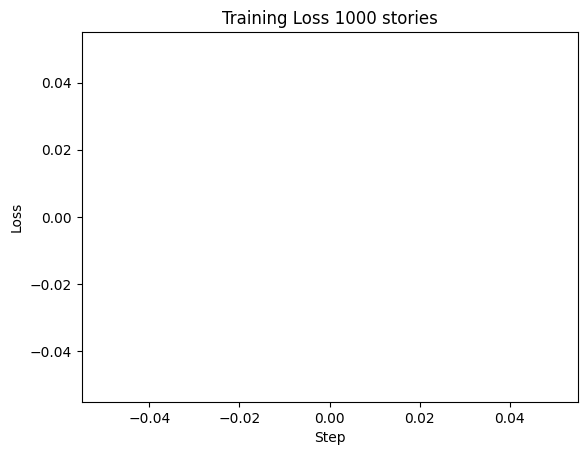

In [29]:
plt.plot(metrics_history["train_loss"])
plt.title("Training Loss 1000 stories")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.show()

## Model Persistance

In [30]:
checkpoint_path = Path.cwd() / "small_checkpoint.orbax"

checkpointer = orbax.checkpoint.PyTreeCheckpointer()

checkpointer.save(checkpoint_path, nnx.state(model), force=True)
print(f"Model saved as {checkpoint_path}")

Model saved as /kaggle/working/small_checkpoint.orbax


## Model Inference

In [31]:
model = MiniGPT()

In [32]:
cpu_device = jax.devices("cpu")[0]
cpu_sharding = SingleDeviceSharding(cpu_device)

In [33]:
restore_args = jax.tree_util.tree_map(
    lambda _: checkpoint.ArrayRestoreArgs(sharding=cpu_sharding), nnx.state(model)
)

# nnx.state(model)

In [34]:
# checkpoint_path = Path.cwd() / "model_checkpoint.orbax"
checkpoint_path = Path.cwd() / "small_checkpoint.orbax"

In [35]:
checkpointer = orbax.checkpoint.PyTreeCheckpointer()

restored_state = checkpointer.restore(
    checkpoint_path, item=nnx.state(model), restore_args=restore_args
)

nnx.update(model, restored_state)

In [36]:
story_prompt = test_df.sample(1)['text'].tolist()[0]
story_prompt

"One day, Mary went to the park. She was feeling very nervous. She looked around and saw an old tree with deep roots. Mary wanted to stay and explore the tree.\n\nSo, Mary walked up to the tree and put both of her hands on the bark. It felt warm and rough. She closed her eyes and took a deep breath. The smells of the park filled her nose. \n\nMary bent down and put her hand on one of the tree's roots. She hoped it would help her stay calm. As she touched the root, she felt better. Her nerves began to disappear.\n\nMary stayed at the tree for a long time, just exploring and touching the roots. She felt peaceful and safe. Finally, when it was time to go home, Mary said goodbye to the old tree and thanked it for helping her stay calm."

In [37]:
def create_story(story_prompt, temperature, max_new_tokens):
    return generate_story(model, story_prompt, temperature, max_new_tokens)


create_story(story_prompt[:100], 0.2, 30)

'One day, Mary went to the park. She was feeling very nervous. She looked around and saw an old tree \n\n"What\'s that?" asked Mary. \n\n"It\'s a tree," said Mary. \n\nMary was scared, but'

In [38]:
# demo = gr.Interface(
#     fn=create_story,
#     inputs=[
#         gr.Textbox(label="Story Prompt"),
#         gr.Slider(minimum=0, maximum=1.0, value=0.8, step=0.01, label="Temperature"),
#         gr.Slider(minimum=0, maximum=200, value=10, step=1, label="Max Tokens"),
#     ],
#     outputs=["text"],
# )

# demo.launch(share=True)